# Puzzle

https://thefiddler.substack.com/p/can-you-tile-the-hexagon

# Fiddler Solution

Each corner of the hexagon has 2 triangles touching it.

Each corner can be in one of 2 states. 

Either it has one tile spanning both triangles (state 1), or it has 2 separate tiles covering the 2 triangles (state 2).

If it is in state 2, then it forces the 2 adjacent vertices of the overall hexagon to be in state 1.

If it is in state 1, then the adjacent vertices of the overall hexagon can be in either state.

So, we get the following possible set of states for the 6 vertices (labelled A to F)

In [5]:
one_two = [1, 2]
count = 0
valid_combinations = []

for a in one_two:
    for b in one_two:
        for c in one_two:
            for d in one_two:
                for e in one_two:
                    for f in one_two:
                        if a + b < 4:
                            if b + c < 4:
                                if c + d < 4:
                                    if d + e < 4:
                                        if e + f < 4:
                                            if f + a < 4:
                                                #print(a, b, c, d, e, f)
                                                valid_combinations.append((a, b, c, d, e, f))
                                                count += 1

print("Total Count:", count)
valid_combinations.sort(key=sum)
print("Valid Combinations (sorted by sum):")
print("A B C D E F")
for combination in valid_combinations:
    for c in combination:
        print(c, end=" ")
    print()

Total Count: 18
Valid Combinations (sorted by sum):
A B C D E F
1 1 1 1 1 1 
1 1 1 1 1 2 
1 1 1 1 2 1 
1 1 1 2 1 1 
1 1 2 1 1 1 
1 2 1 1 1 1 
2 1 1 1 1 1 
1 1 1 2 1 2 
1 1 2 1 1 2 
1 1 2 1 2 1 
1 2 1 1 1 2 
1 2 1 1 2 1 
1 2 1 2 1 1 
2 1 1 1 2 1 
2 1 1 2 1 1 
2 1 2 1 1 1 
1 2 1 2 1 2 
2 1 2 1 2 1 


So, grouping these, we have 5 cases that we need to analyze further, whcih I have named for clarity:

* **ALPHA**: All 1's - 1 way.
* **BRAVO**: Single 2 - 6 ways
* **CHARLIE**: Two 2's separated by one 1 - 6 ways.
* **DELTA**: Two 2's separated by two 1's  - 3 ways.
* **ECHO**: Three 2's separated by 1's - 2 ways.


### ALPHA

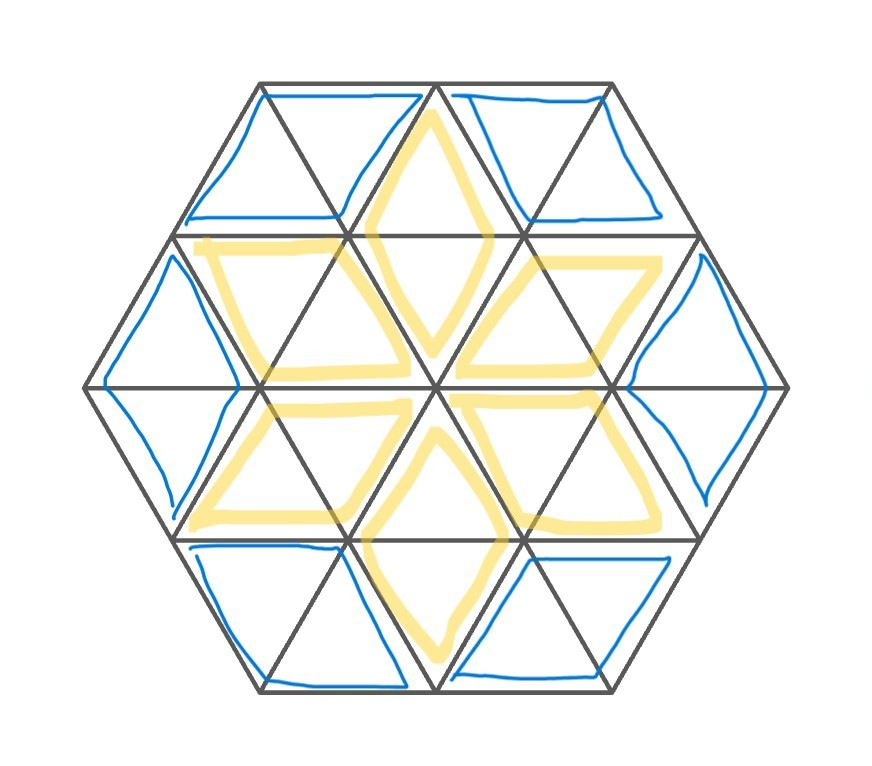

Setting the corner tiles (blue) forces exactly one possible arrangement for the inner tiles (yellow). This is a really nice looking arrangement.

### BRAVO

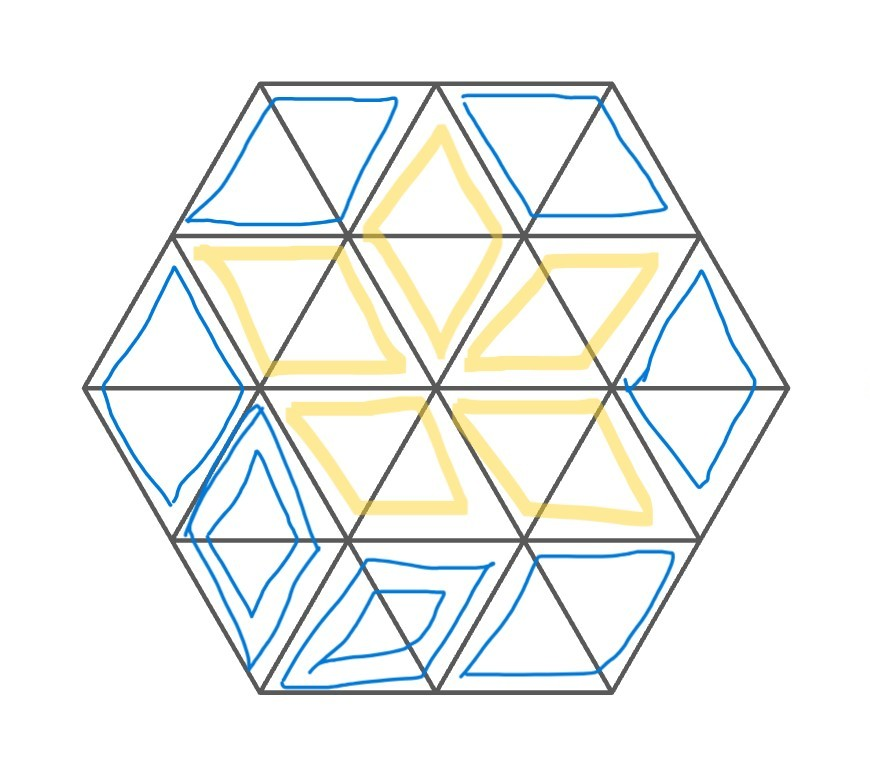

Here too the corner tiles force exactly one arrangement for the inner tiles.

### CHARLIE

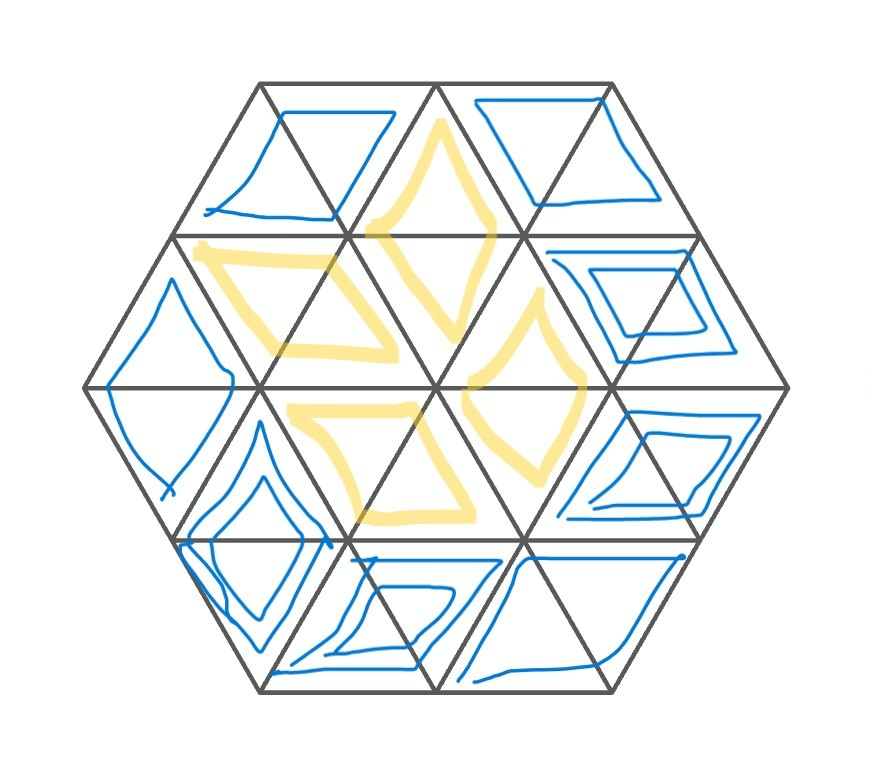

Here too the corner tiles force exactly one arrangement for the inner tiles.

### DELTA

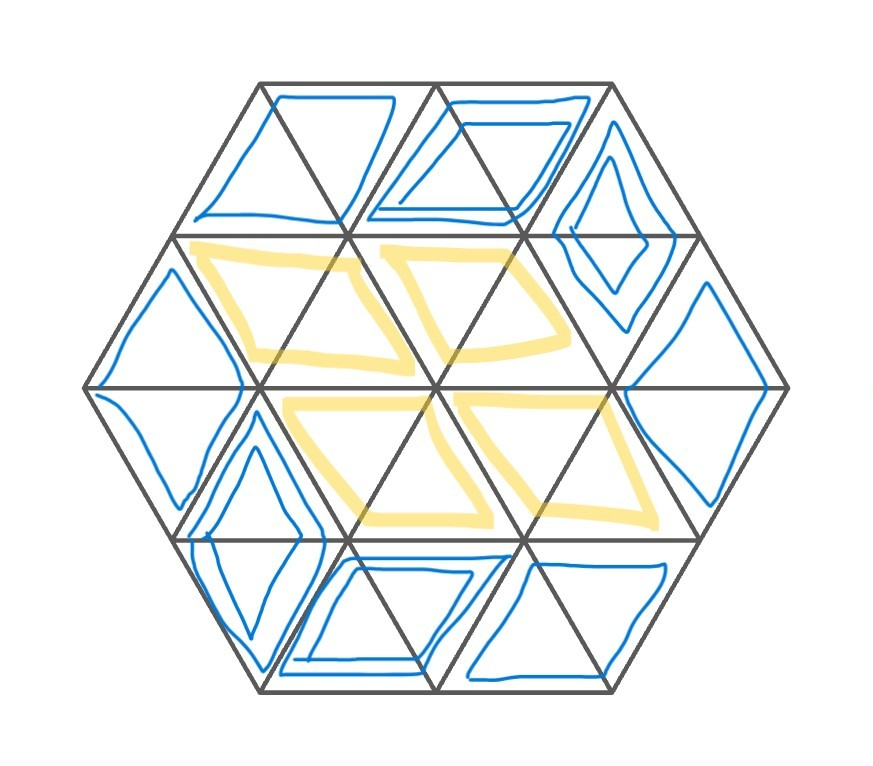

Here too the corner tiles force exactly one arrangement for the inner tiles.

### ECHO

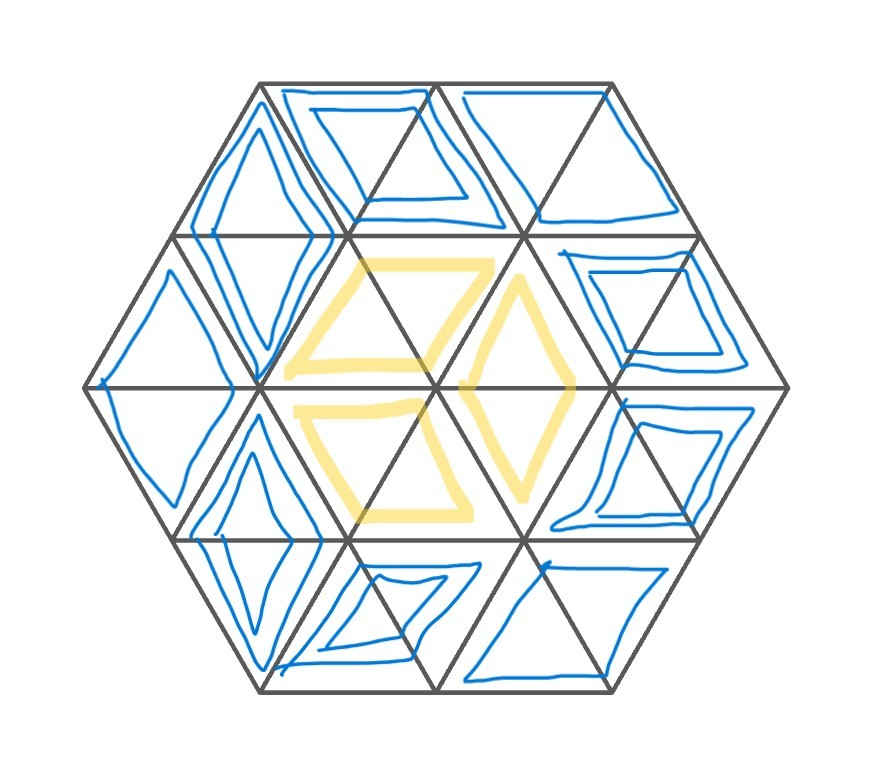

Here there are 2 arrangements possible for the inner tiles.

### TOGETHER

| Case | Corner Ways | Inner Ways | Product|
|-|-|-|-|
|ALPHA   | 1 | 1 | 1 |
|BRAVO   | 6 | 1 | 6 |
|CHARLIE | 6 | 1 | 6 |
|DELTA   | 3 | 1 | 3 |
|ECHO    | 2 | 2 | 4 |

Total : 20 ways to arrange the tiles

# Extra Credit

Um, it is feeling tedious to code up something to find the ways for the EC. I am wondering if I can estimate it without code.

We have :
* WaysToTile(1) = 2 
* WaysToTile(2) = 20
* WaysToTile(3) = ?

Well, first thing is that here too we have the same structure that if a corner is in state 2, it forces adjacent corners to be in state 1. So, we have exactly the same list of 18 cases divided into 5 groups (alpha, bravo, charlie, delta, echo). But the inner ways are different.

In the ECHO state, the outer ring is fully determined, so the inner ways are 20 (from the Fiddler). That leaves the other 4 configurations to be sorted out.

In the DELTA state, a good part of the outer ring is determined, but what's left is a regular hexagon with some odd-sized bits at the end. So, maybe it has more than 20 options, but not certain.

I'll come back to this, but giving up for now.

I am guessing that each of the 18 outer cases has at least 20 inner ways, so the total should be over 360. But's that's very approximate.